# TextMamba3D — TC Regression Ablation

V4.5 ET improved (+1.16%), but TC dropped from V4.4's 0.8512 to 0.8396 (-1.16pp).
Three inference-time tests, no retraining, to diagnose root cause.

| Test | Checkpoint | Text Input | Purpose |
|------|-----------|------------|--------|
| 1 | V4.5 | Original only | Isolate enriched text effect at inference |
| 2 | V4.4 | Original only | Reproduce V4.4 baseline |
| 3 | V4.5 | Enriched | Reference (re-run for per-case data) |

**Diagnostic logic:**
- `inference_effect = Test3.TC - Test1.TC`
- `training_effect  = Test1.TC - Test2.TC`
- Whichever is larger = primary cause

**Prerequisites:** Run V4.5 notebook Sections 1-4 first (code patches + data extraction + ET text generation).

In [1]:
# 1. Environment Setup
from google.colab import drive
drive.mount('/content/drive')

!nvidia-smi 2>/dev/null || echo "No GPU detected"
!pip install -q --cache-dir=/content/drive/MyDrive/pip_cache mamba-ssm causal-conv1d transformers nibabel tensorboard pyyaml tqdm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Wed Mar 18 03:18:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|          

In [2]:
# 2. Restore Code + Data from Drive
import os, zipfile, shutil

REPO_DIR = '/content/TextMamba3D'
DRIVE_BASE = '/content/drive/MyDrive/TextMamba3D'
DRIVE_CKPT = os.path.join(DRIVE_BASE, 'checkpoints')
DRIVE_CODE_ZIP = os.path.join(DRIVE_BASE, 'TextMamba3D_code.zip')
DATA_DIR = os.path.join(REPO_DIR, 'data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData')
DATA_ZIP = os.path.join(DRIVE_BASE, 'TextBraTS_data.zip')

# Code
if not os.path.exists(os.path.join(REPO_DIR, 'models/textmamba3d.py')):
    os.makedirs(REPO_DIR, exist_ok=True)
    with zipfile.ZipFile(DRIVE_CODE_ZIP, 'r') as zf:
        zf.extractall(REPO_DIR)
    print(f'Code extracted to {REPO_DIR}')
else:
    print(f'Code already at {REPO_DIR}')

# Data
if not os.path.exists(DATA_DIR):
    os.makedirs(os.path.dirname(DATA_DIR), exist_ok=True)
    with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
        zf.extractall(os.path.dirname(DATA_DIR))
    print(f'Data extracted: {len(os.listdir(DATA_DIR))} cases')
else:
    print(f'Data exists: {len(os.listdir(DATA_DIR))} cases')

os.chdir(REPO_DIR)
print(f'Working directory: {os.getcwd()}')

Code already at /content/TextMamba3D
Data exists: 371 cases
Working directory: /content/TextMamba3D


In [3]:
# 3. Apply V4.4/V4.5 Code Patches (idempotent)
import pathlib, shutil as _shutil

# 3a. SeqCA in fusion.py
fusion_path = pathlib.Path('models/fusion.py')
if 'SequentialCrossAttention' in fusion_path.read_text():
    print('[3a] SeqCA already in fusion.py')
else:
    raise RuntimeError('SeqCA not found in fusion.py. Run V4.5 notebook Section 3 first.')

# 3b. Check textmamba3d.py uses MultiScaleSeqCA
tm_path = pathlib.Path('models/textmamba3d.py')
if 'MultiScaleSeqCA' in tm_path.read_text():
    print('[3b] textmamba3d.py uses MultiScaleSeqCA')
else:
    raise RuntimeError('MultiScaleSeqCA not in textmamba3d.py. Run V4.5 notebook Section 3 first.')

# 3c. Check dataset has et_enriched support
ds_path = pathlib.Path('data/brats_textbrats_dataset.py')
if 'et_enriched' in ds_path.read_text():
    print('[3c] Dataset has et_enriched support')
else:
    raise RuntimeError('et_enriched not in dataset. Run V4.5 notebook Section 3 first.')

# 3d. Check ET-enriched text files exist
sample = sorted(d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d)))[0]
if os.path.exists(os.path.join(DATA_DIR, sample, f'{sample}_et_enriched.txt')):
    print('[3d] ET-enriched text files present')
else:
    raise RuntimeError('ET-enriched text not found. Run V4.5 notebook Section 4 first.')

# Clear caches
for cache in ['models/__pycache__', 'data/__pycache__']:
    p = pathlib.Path(cache)
    if p.exists():
        _shutil.rmtree(p)

print('All patches verified.')

[3a] SeqCA already in fusion.py
[3b] textmamba3d.py uses MultiScaleSeqCA
[3c] Dataset has et_enriched support
[3d] ET-enriched text files present
All patches verified.


In [4]:
# 4. Generate Ablation Configs + Verify Checkpoints
import yaml, copy, re
import numpy as np

# Load V4.5 config as base
with open('configs/textbrats_v7.yaml', 'r') as f:
    v7 = yaml.safe_load(f)

# Config for Test 1: V4.5 model, original text only
cfg_v45_orig = copy.deepcopy(v7)
cfg_v45_orig['data']['et_enriched'] = False
cfg_v45_orig['experiment']['name'] = 'ablation_v45_original_text'
with open('configs/ablation_v45_orig.yaml', 'w') as f:
    yaml.dump(cfg_v45_orig, f, default_flow_style=False, sort_keys=False)
print('[1] ablation_v45_orig.yaml (V4.5 weights, original text, max_len=192)')

# Config for Test 2: V4.4 model (text_max_len=128)
cfg_v44 = copy.deepcopy(v7)
cfg_v44['data']['et_enriched'] = False
cfg_v44['data'].pop('enriched_prob', None)
cfg_v44['model']['text_max_len'] = 128
cfg_v44['experiment']['name'] = 'ablation_v44_baseline'
with open('configs/ablation_v44.yaml', 'w') as f:
    yaml.dump(cfg_v44, f, default_flow_style=False, sort_keys=False)
print('[2] ablation_v44.yaml (V4.4 weights, original text, max_len=128)')

# Verify checkpoints
v45_ckpt = os.path.join(DRIVE_CKPT, 'best_v4.5.pth')
v44_ckpt = os.path.join(DRIVE_CKPT, 'best_v4.4.pth')

all_ok = True
for name, path in [('V4.5', v45_ckpt), ('V4.4', v44_ckpt)]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f'  {name}: {size_mb:.1f} MB')
    else:
        print(f'  {name}: NOT FOUND at {path}')
        all_ok = False

assert all_ok, 'Missing checkpoint(s)!'

# Log parser
def parse_eval_log(log_path):
    """Parse evaluate_full.py output -> (per_case_list, summary_dict)."""
    if not os.path.exists(log_path):
        print(f'WARNING: {log_path} not found')
        return [], {}
    results, summary = [], {}
    case_pat = re.compile(
        r'(BraTS20_Training_\d+): Dice=([\d.]+) '
        r'\(ET=([\d.]+), TC=([\d.]+), WT=([\d.]+)\) '
        r'HD95_ET=([\d.]+|nan)'
    )
    sum_pat = re.compile(r'\s+(dice_\w+|hd95_\w+): ([\d.]+) \+/- ([\d.]+)')
    with open(log_path, 'r') as f:
        for line in f:
            m = case_pat.search(line)
            if m:
                results.append({
                    'case': m.group(1),
                    'dice_mean': float(m.group(2)),
                    'dice_ET': float(m.group(3)),
                    'dice_TC': float(m.group(4)),
                    'dice_WT': float(m.group(5)),
                    'hd95_ET': float(m.group(6)) if m.group(6) != 'nan' else float('nan'),
                })
            m2 = sum_pat.search(line)
            if m2:
                summary[m2.group(1)] = {'mean': float(m2.group(2)), 'std': float(m2.group(3))}
    print(f'  Parsed {log_path}: {len(results)} cases')
    return results, summary

print('Ready. Run next cell (~45 min on A100).')

[1] ablation_v45_orig.yaml (V4.5 weights, original text, max_len=192)
[2] ablation_v44.yaml (V4.4 weights, original text, max_len=128)
  V4.5: 788.5 MB
  V4.4: 788.5 MB
Ready. Run next cell (~45 min on A100).


In [5]:
# 5. Run Three Evaluations (~15 min each)
os.chdir(REPO_DIR)

print('=' * 60)
print('Test 1/3: V4.5 checkpoint + ORIGINAL text')
print('=' * 60)
!python evaluate_full.py \
    --config configs/ablation_v45_orig.yaml \
    --checkpoint {v45_ckpt} \
    --split test --use-text --overlap 0.5 \
    2>&1 | tee ablation_test1.log

print()
print('=' * 60)
print('Test 2/3: V4.4 checkpoint + ORIGINAL text')
print('=' * 60)
!python evaluate_full.py \
    --config configs/ablation_v44.yaml \
    --checkpoint {v44_ckpt} \
    --split test --use-text --overlap 0.5 \
    2>&1 | tee ablation_test2.log

print()
print('=' * 60)
print('Test 3/3: V4.5 checkpoint + ENRICHED text')
print('=' * 60)
!python evaluate_full.py \
    --config configs/textbrats_v7.yaml \
    --checkpoint {v45_ckpt} \
    --split test --use-text --overlap 0.5 \
    2>&1 | tee ablation_test3.log

# Backup to Drive
log_dir = os.path.join(DRIVE_BASE, 'ablation_logs')
os.makedirs(log_dir, exist_ok=True)
for log in ['ablation_test1.log', 'ablation_test2.log', 'ablation_test3.log']:
    if os.path.exists(log):
        shutil.copy2(log, os.path.join(log_dir, log))
print(f'Logs saved to {log_dir}')

Test 1/3: V4.5 checkpoint + ORIGINAL text
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5699.41it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loa

In [6]:
# 6. Analysis + Wilcoxon Test
from scipy import stats
os.chdir(REPO_DIR)

r1, s1 = parse_eval_log('ablation_test1.log')   # V4.5 + original
r2, s2 = parse_eval_log('ablation_test2.log')   # V4.4 + original
r3, s3 = parse_eval_log('ablation_test3.log')   # V4.5 + enriched

d1 = {r['case']: r for r in r1}
d2 = {r['case']: r for r in r2}
d3 = {r['case']: r for r in r3}
common = sorted(set(d1) & set(d2) & set(d3))
print(f'Paired test cases: {len(common)}')
assert len(common) > 0, 'No common cases. Check evaluations completed.'

# Summary
print()
print('=' * 70)
header = '{:<35} {:>8} {:>8} {:>8} {:>8}'.format('Condition', 'ET', 'TC', 'WT', 'Mean')
print(header)
print('-' * 70)
for label, s in [
    ('V4.5 + enriched text', s3),
    ('V4.5 + original text', s1),
    ('V4.4 + original text', s2),
]:
    if 'dice_ET' in s:
        row = '{:<35} {:>8.4f} {:>8.4f} {:>8.4f} {:>8.4f}'.format(
            label, s['dice_ET']['mean'], s['dice_TC']['mean'],
            s['dice_WT']['mean'], s['dice_mean']['mean'])
        print(row)
    else:
        print('{:<35}  (not available)'.format(label))

# Diagnostic 1: Enriched text at inference
print()
print('=' * 70)
print('DIAGNOSTIC 1: Enriched text at inference (V4.5 enriched - V4.5 original)')
print('=' * 70)
for metric in ['dice_ET', 'dice_TC', 'dice_WT', 'dice_mean']:
    vals_e = [d3[c][metric] for c in common]
    vals_o = [d1[c][metric] for c in common]
    delta = np.mean(vals_e) - np.mean(vals_o)
    try:
        _, p = stats.wilcoxon(vals_e, vals_o)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print('  {:<12} {:+.4f}  p={:.4f} {}'.format(metric, delta, p, sig))
    except ValueError:
        print('  {:<12} {:+.4f}  (identical)'.format(metric, delta))

# Diagnostic 2: Training weight change
print()
print('=' * 70)
print('DIAGNOSTIC 2: Training weight change (V4.5 orig - V4.4 orig)')
print('=' * 70)
for metric in ['dice_ET', 'dice_TC', 'dice_WT', 'dice_mean']:
    vals_v45 = [d1[c][metric] for c in common]
    vals_v44 = [d2[c][metric] for c in common]
    delta = np.mean(vals_v45) - np.mean(vals_v44)
    try:
        _, p = stats.wilcoxon(vals_v45, vals_v44)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print('  {:<12} {:+.4f}  p={:.4f} {}'.format(metric, delta, p, sig))
    except ValueError:
        print('  {:<12} {:+.4f}  (identical)'.format(metric, delta))

# Top 10 TC regressions
print()
print('=' * 70)
print('TOP 10 TC REGRESSIONS (V4.5 enriched vs V4.4)')
print('=' * 70)
tc_rows = [(c, d2[c]['dice_TC'], d3[c]['dice_TC'], d1[c]['dice_TC'],
            d3[c]['dice_TC'] - d2[c]['dice_TC']) for c in common]
tc_rows.sort(key=lambda x: x[4])
print('{:<26} {:>7} {:>7} {:>7} {:>7}'.format('Case', 'V4.4', 'V4.5e', 'V4.5o', 'delta'))
print('-' * 60)
for case, v44, v45e, v45o, delta in tc_rows[:10]:
    print('{:<26} {:.4f} {:.4f} {:.4f} {:+.4f}'.format(case, v44, v45e, v45o, delta))

  Parsed ablation_test1.log: 95 cases
  Parsed ablation_test2.log: 95 cases
  Parsed ablation_test3.log: 95 cases
Paired test cases: 95

Condition                                 ET       TC       WT     Mean
----------------------------------------------------------------------
V4.5 + enriched text                  0.7720   0.8396   0.8927   0.8348
V4.5 + original text                  0.7612   0.8394   0.8927   0.8311
V4.4 + original text                  0.7631   0.8513   0.8887   0.8343

DIAGNOSTIC 1: Enriched text at inference (V4.5 enriched - V4.5 original)
  dice_ET      +0.0108  p=0.8300 ns
  dice_TC      +0.0003  p=0.1612 ns
  dice_WT      +0.0000  p=0.9780 ns
  dice_mean    +0.0037  p=0.6792 ns

DIAGNOSTIC 2: Training weight change (V4.5 orig - V4.4 orig)
  dice_ET      -0.0019  p=0.0159 *
  dice_TC      -0.0119  p=0.7159 ns
  dice_WT      +0.0040  p=0.0018 **
  dice_mean    -0.0033  p=0.2246 ns

TOP 10 TC REGRESSIONS (V4.5 enriched vs V4.4)
Case                          V4.4

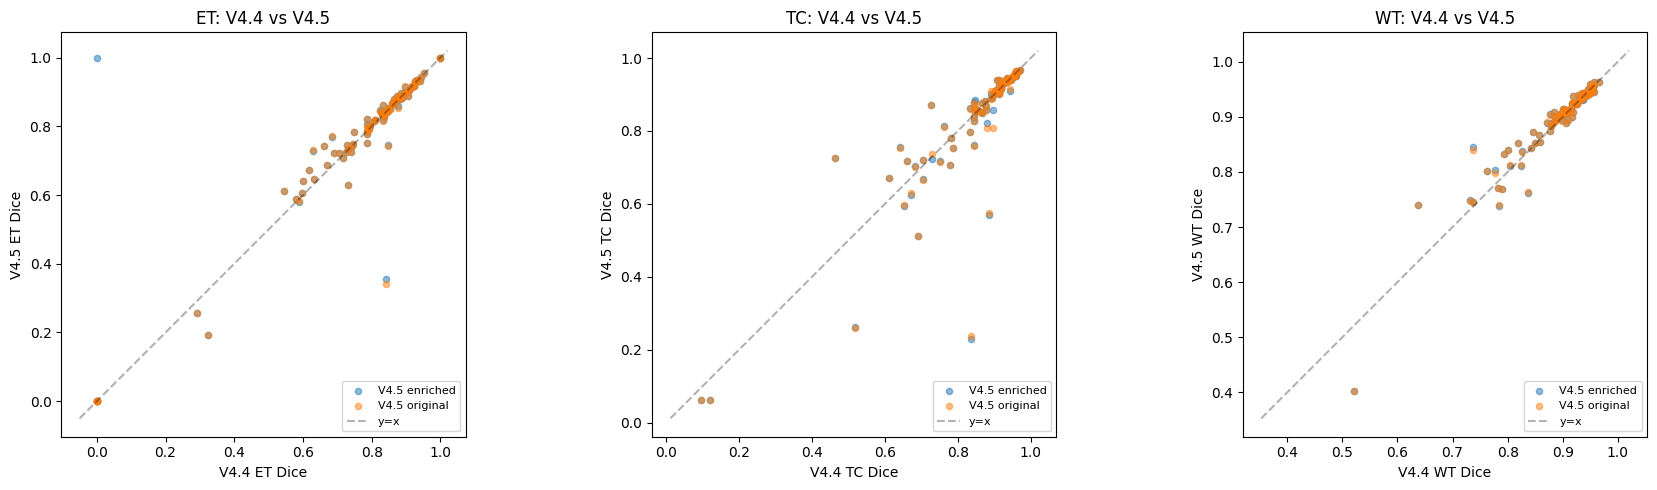


DIAGNOSIS
  Inference effect (enriched - original text): +0.0003
  Training effect  (V4.5 - V4.4 weights):     -0.0119
  Total TC change  (V4.5 enriched - V4.4):     -0.0116

  --> TC regression PRIMARILY from training weight shift.
  --> Fix: region-specific text enrichment during training.


In [7]:
# 7. Visualization + Diagnosis
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(
    axes, ['dice_ET', 'dice_TC', 'dice_WT'], ['ET', 'TC', 'WT'],
):
    v44 = [d2[c][metric] for c in common]
    v45e = [d3[c][metric] for c in common]
    v45o = [d1[c][metric] for c in common]
    ax.scatter(v44, v45e, alpha=0.5, s=20, label='V4.5 enriched', c='tab:blue')
    ax.scatter(v44, v45o, alpha=0.5, s=20, label='V4.5 original', c='tab:orange')
    lo = min(min(v44), min(v45e), min(v45o)) - 0.05
    ax.plot([lo, 1.02], [lo, 1.02], 'k--', alpha=0.3, label='y=x')
    ax.set_xlabel(f'V4.4 {title} Dice')
    ax.set_ylabel(f'V4.5 {title} Dice')
    ax.set_title(f'{title}: V4.4 vs V4.5')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('ablation_tc_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Auto-diagnosis ──
print()
print('=' * 70)
print('DIAGNOSIS')
print('=' * 70)
tc_inf = np.mean([d3[c]['dice_TC'] for c in common]) - np.mean([d1[c]['dice_TC'] for c in common])
tc_trn = np.mean([d1[c]['dice_TC'] for c in common]) - np.mean([d2[c]['dice_TC'] for c in common])
tc_tot = np.mean([d3[c]['dice_TC'] for c in common]) - np.mean([d2[c]['dice_TC'] for c in common])

print(f'  Inference effect (enriched - original text): {tc_inf:+.4f}')
print(f'  Training effect  (V4.5 - V4.4 weights):     {tc_trn:+.4f}')
print(f'  Total TC change  (V4.5 enriched - V4.4):     {tc_tot:+.4f}')
print()
if abs(tc_inf) > abs(tc_trn) * 2:
    print('  --> TC regression PRIMARILY from enriched text at inference.')
    print('  --> Fix: eval with original text for TC; enriched text only for ET.')
elif abs(tc_trn) > abs(tc_inf) * 2:
    print('  --> TC regression PRIMARILY from training weight shift.')
    print('  --> Fix: region-specific text enrichment during training.')
else:
    print('  --> TC regression from BOTH inference text AND training weights.')
    print('  --> Fix: need region-specific enrichment + training strategy.')